In [68]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

#### Get the flood dataset

In [69]:
# MERGED TWICE TO REMOVE DUPLICATES

flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()
print(flood_county.info())
print(flood_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35450 entries, 0 to 35449
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FIPS                   35450 non-null  int64  
 1   YEAR                   35450 non-null  int64  
 2   STATE                  35450 non-null  object 
 3   CZ_NAME                35450 non-null  object 
 4   COUNT                  35450 non-null  int64  
 5   TOTAL_DAMAGE_PROPERTY  35450 non-null  float64
 6   TOTAL_DURATION_HOURS   35450 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.9+ MB
None
               FIPS          YEAR         COUNT  TOTAL_DAMAGE_PROPERTY  \
count  35450.000000  35450.000000  35450.000000           3.545000e+04   
mean   30434.366008   2010.019069     13.039126           3.367555e+06   
std    14880.622613      6.061159     18.316309           1.256051e+08   
min     1001.000000   2000.000000      1.000000           0.0

#### Get the HPI dataset

In [70]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()
print(hpi_county.info())
print(hpi_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21965 entries, 0 to 21964
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cbsa_code                 21965 non-null  int64  
 1   cbsa_title                21965 non-null  object 
 2   county_fips5              21965 non-null  int64  
 3   county/county_equivalent  21965 non-null  object 
 4   state_name                21965 non-null  object 
 5   place_name                21965 non-null  object 
 6   place_id                  21965 non-null  int64  
 7   yr                        21965 non-null  int64  
 8   index_nsa                 21965 non-null  float64
 9   index_prev                21965 non-null  float64
 10  hpi_change                21965 non-null  float64
 11  hpi_yoy                   21965 non-null  float64
dtypes: float64(4), int64(4), object(4)
memory usage: 2.0+ MB
None
          cbsa_code  county_fips5      place_id       

#### Checking for missing counties

In [71]:
# hpi_county[hpi_county["cbsa_code"] == "10100"]
flood_county[flood_county["FIPS"] == "46045"]

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS


In [72]:
min(hpi_county["county_fips5"]), max(hpi_county["county_fips5"])

(1001, 56025)

In [73]:
mask = ~hpi_county["county_fips5"].isin(flood_county["FIPS"])
hpi_no_flood = hpi_county.loc[mask, "county_fips5"].unique()
hpi_no_flood

array([ 2170, 41031,  9120,  9190,  2090,  9110,  9130, 15005,  9170,
        9180, 53059, 13173,  9140])

In [74]:
mask = ~flood_county["FIPS"].isin(hpi_county["county_fips5"])
flood_no_hpi = flood_county.loc[mask, "FIPS"].unique()
flood_no_hpi

array([ 1005,  1011,  1013, ..., 56041, 56043, 56045])

#### Merge flood and HPI datasets

In [75]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_yoy"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="left",
)

# Identify columns that came from flood_county (excluding join keys)
flood_cols = [c for c in flood_county.columns if c not in ["FIPS", "YEAR"]]

# Impute those flood variables as 0
hpi_flood[flood_cols] = hpi_flood[flood_cols].fillna(0)

# Drop join-key duplicates from the merged df
hpi_flood = hpi_flood.drop(columns=["FIPS", "YEAR"])

hpi_flood.head()

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,48059,2000,1.226954,0,0,0.0,0.0,0.00
1,48059,2001,4.070521,0,0,0.0,0.0,0.00
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18


In [76]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Get heat dataset

In [77]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [78]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [79]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


In [80]:
# CHECKING FOR DUPLICATES
temp = (
    heat_county.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Merge heat and HPI/flood datasets

In [81]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Identify columns that came from heat_county, excluding join keys
heat_cols = ["FIPS", "year", "value", "heat_index", "HSI"]

# Impute only heat-related variables as 0
hpi_flood_heat[heat_cols] = hpi_flood_heat[heat_cols].fillna(0)

# Drop join-key duplicates
hpi_flood_heat = hpi_flood_heat.drop(columns=["FIPS", "year"])

hpi_flood_heat.head()
hpi_flood_heat

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233
...,...,...,...,...,...,...,...,...,...,...,...
21960,4027,2016,3.794342,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492
21961,4027,2017,3.854183,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639
21962,4027,2018,3.642268,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690
21963,4027,2019,5.189345,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888


In [82]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge the drought and wildfire datasets

In [83]:
drought_county = pd.read_csv(
    "../../02_processed_data/NCEI_annual_drought_county_FINAL.csv"
).reset_index(drop=True)
drought_county = drought_county[drought_county["FIPS"] != 0]
drought_county.sort_values(by=["FIPS", "Year"]).dropna()
drought_county = drought_county.drop(["County", "State", "State_abbr"], axis=1)

In [84]:
dupes = drought_county[drought_county.duplicated(subset=["FIPS", "Year"], keep=False)]
dupes = dupes.sort_values(by=["FIPS", "Year"])
drought_county = drought_county.drop_duplicates(subset=["FIPS", "Year"], keep="first")
drought_county.head()

,FIPS,Year,Annual_Mean_Index
0,1001,2000,-2.32
1,1001,2001,1.43
2,1001,2002,-0.76
3,1001,2003,2.39
4,1001,2004,0.00


In [ ]:
drought_hpi_flood_heat = pd.merge(
    hpi_flood_heat,
    drought_county[["FIPS", "Year", "Annual_Mean_Index"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

drought_hpi_flood_heat = drought_hpi_flood_heat.drop(columns=["FIPS", "Year"])

drought_hpi_flood_heat["Annual_Mean_Index"] = drought_hpi_flood_heat[
    "Annual_Mean_Index"
].fillna(0)

drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28


In [86]:
# CHECKING FOR DUPLICATES
temp = (
    drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


In [87]:
wildfire_county = pd.read_csv(
    "../../02_processed_data/wildfire_data_preprocessed.csv"
).reset_index(drop=True)
wildfire_county.sort_values(by=["FIPS", "Year"]).dropna()
wildfire_county = wildfire_county.drop(["State"], axis=1)
wildfire_county.head()

,FIPS,Year,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,1001,2003,43,274.8
1,1001,2004,86,744.5
2,1001,2005,63,234.2
3,1001,2006,62,534.7
4,1001,2007,93,477.3


In [ ]:
wildfire_drought_hpi_flood_heat = pd.merge(
    drought_hpi_flood_heat,
    wildfire_county[["FIPS", "Year", "FIRE_FREQUENCY", "TOTAL_FIRE_SIZE"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

wildfire_drought_hpi_flood_heat = wildfire_drought_hpi_flood_heat.drop(
    columns=["FIPS", "Year"]
)

wildfire_drought_hpi_flood_heat["FIRE_FREQUENCY"] = wildfire_drought_hpi_flood_heat[
    "FIRE_FREQUENCY"
].fillna(0)
wildfire_drought_hpi_flood_heat["TOTAL_FIRE_SIZE"] = wildfire_drought_hpi_flood_heat[
    "TOTAL_FIRE_SIZE"
].fillna(0)

wildfire_drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.0
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.0
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.0
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.0
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.0


In [89]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge Drought/Wildfire/HPI/Flood/Heat/Hurricane datasets

In [90]:
storm_summary = pd.read_csv(
    "../../02_processed_data/storm_data_aggregated_county.csv", low_memory=False
)
storm_summary["year"] = storm_summary["year"].astype("int")
storm_summary["FIPS"] = storm_summary["FIPS"].astype("int")

huricane_grouped = storm_summary.groupby(["FIPS", "year"], as_index=False).agg(
    deaths_hurricane=("deaths", "sum"),
    injuries_hurricane=("injuries", "sum"),
    damage_hurricane=("damage", "sum"),
)

huricane_grouped.sort_values(by=["FIPS", "year"])

,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1003,2002,0.0,0.0,75000
1,1003,2004,0.0,0.0,0
2,1003,2005,0.0,0.0,0
3,1003,2020,2.0,0.0,236080000
4,1013,2004,0.0,0.0,0
...,...,...,...,...,...
947,51730,2003,1.0,0.0,9700000
948,51740,2003,0.0,0.0,10000000
949,51800,2003,0.0,0.0,33000000
950,51810,2003,0.0,0.0,39400000


In [91]:
wildfire_drought_hpi_flood_heat_huricane = pd.merge(
    wildfire_drought_hpi_flood_heat,
    huricane_grouped,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Columns coming from huricane_grouped, excluding join keys
hurricane_cols = [c for c in huricane_grouped.columns if c not in ["FIPS", "year"]]

# Impute only hurricane variables as 0
wildfire_drought_hpi_flood_heat_huricane[hurricane_cols] = (
    wildfire_drought_hpi_flood_heat_huricane[hurricane_cols].fillna(0)
)


wildfire_drought_hpi_flood_heat_huricane

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.00,NaN,NaN,0.0,0.0,0.0
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.00,NaN,NaN,0.0,0.0,0.0
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.00,NaN,NaN,0.0,0.0,0.0
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.00,NaN,NaN,0.0,0.0,0.0
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.00,NaN,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21960,4027,2016,3.794342,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492,-2.68,11.0,1326.60,NaN,NaN,0.0,0.0,0.0
21961,4027,2017,3.854183,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639,-2.05,17.0,103.00,NaN,NaN,0.0,0.0,0.0
21962,4027,2018,3.642268,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690,-2.95,191.0,594.87,NaN,NaN,0.0,0.0,0.0
21963,4027,2019,5.189345,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888,-0.23,64.0,1265.91,NaN,NaN,0.0,0.0,0.0


In [ ]:
df = wildfire_drought_hpi_flood_heat_huricane

# columns to drop
cols_to_drop = [
    "YEAR",
    "year_y",
    "State_fire",
    "State_ncei",
    "State_abbr",
    "Year",
    "county_fips5",
    "year_x",
    "FIPS",
    "year",
]

# drop them from df (ignore any that might be missing)
df = df.drop(columns=cols_to_drop, errors="ignore")

# quick check
print(df.columns)
print(df.info())
print(df.describe())

Index(['yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'COUNT', 'TOTAL_DAMAGE_PROPERTY',
       'TOTAL_DURATION_HOURS', 'value', 'heat_index', 'HSI',
       'Annual_Mean_Index', 'FIRE_FREQUENCY', 'TOTAL_FIRE_SIZE',
       'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21965 entries, 0 to 21964
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     21965 non-null  int64  
 1   hpi_yoy                21965 non-null  float64
 2   STATE                  21965 non-null  object 
 3   CZ_NAME                21965 non-null  object 
 4   COUNT                  21965 non-null  float64
 5   TOTAL_DAMAGE_PROPERTY  21965 non-null  float64
 6   TOTAL_DURATION_HOURS   21965 non-null  float64
 7   value                  21965 non-null  float64
 8   heat_index             21965 non-null  float64
 9   HSI               

In [93]:
df = df.rename(
    columns={
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        # "HSI": "HEAT_HSI",
    }
)
df.columns

Index(['yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE',
       'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY',
       'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

In [ ]:
from pathlib import Path

user_path = input(
    "/Users/ramilmammadov/Desktop/Capstone Project/GitHub Repo/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data"
).strip()
p = Path(user_path)

if p.suffix.lower() != ".csv":
    p.mkdir(parents=True, exist_ok=True)
    p = p / "wildfire_drought_hpi_flood_heat_hurricane_clean.csv"

df.to_csv(p, index=False, encoding="utf-8")
print(f"Saved to: {p}")

Saved to: /Users/ramilmammadov/Desktop/Capstone Project/GitHub Repo/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/wildfire_drought_hpi_flood_heat_hurricane_clean.csv


In [ ]:
# -------------------------------
# 2) Missing values per column
# -------------------------------
missing_summary = (
    pd.DataFrame(
        {
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "non_null": df.notna().sum().values,
            "missing": df.isna().sum().values,
        }
    )
    .assign(missing_pct=lambda d: d["missing"] / len(df) * 100)
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)
print("\nMissing values by column (top 20):")
print(
    missing_summary.head(20).to_string(
        index=False, formatters={"missing_pct": "{:.2f}%".format}
    )
)


Missing values by column (top 20):
                   column   dtype  non_null  missing missing_pct
                       yr   int64     21965        0       0.00%
                  hpi_yoy float64     21965        0       0.00%
                    STATE  object     21965        0       0.00%
                  CZ_NAME  object     21965        0       0.00%
          FLOOD_FREQUENCY float64     21965        0       0.00%
    FLOOD_PROPERTY_DAMAGE float64     21965        0       0.00%
     FLOOD_DURATION_HOURS float64     21965        0       0.00%
               HEAT_VALUE float64     21965        0       0.00%
               HEAT_INDEX float64     21965        0       0.00%
                      HSI float64     21965        0       0.00%
DROUGHT_ANNUAL_MEAN_INDEX float64     21965        0       0.00%
           FIRE_FREQUENCY float64     21965        0       0.00%
                FIRE_SIZE float64     21965        0       0.00%
         deaths_hurricane float64     21965        0  

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21965 entries, 0 to 21964
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   yr                         21965 non-null  int64  
 1   hpi_yoy                    21965 non-null  float64
 2   STATE                      21965 non-null  object 
 3   CZ_NAME                    21965 non-null  object 
 4   FLOOD_FREQUENCY            21965 non-null  float64
 5   FLOOD_PROPERTY_DAMAGE      21965 non-null  float64
 6   FLOOD_DURATION_HOURS       21965 non-null  float64
 7   HEAT_VALUE                 21965 non-null  float64
 8   HEAT_INDEX                 21965 non-null  float64
 9   HSI                        21965 non-null  float64
 10  DROUGHT_ANNUAL_MEAN_INDEX  21965 non-null  float64
 11  FIRE_FREQUENCY             21965 non-null  float64
 12  FIRE_SIZE                  21965 non-null  float64
 13  deaths_hurricane           21965 non-null  float64


In [ ]:
# -------------------------------
# 3) Target & features
# -------------------------------
# Robust target detection
target_candidates = [c for c in df.columns if c.lower() == "hpi_yoy"]
if not target_candidates:
    raise ValueError(
        "Target column 'hpi_yoy' not found. Please rename your target or adjust the code."
    )
target_col = target_candidates[0]

# Drop rows with missing/non-numeric target
y = pd.to_numeric(df[target_col], errors="coerce")
mask = y.notna()
if mask.sum() < len(df):
    print(
        f"\nDropping {len(df) - mask.sum():,} rows due to missing/non-numeric target '{target_col}'."
    )
df = df.loc[mask].copy()
y = y.loc[mask]

# Use ALL other columns as features
X = df.drop(columns=[target_col])

# Split numeric vs categorical based on dtype
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# Ensure categorical columns are uniform type (strings) to avoid mixed-type OHE errors
X[categorical_cols] = X[categorical_cols].astype("string")


Numeric features: 13
Categorical features: 2


In [ ]:
# -------------------------------
# 4) 70/10/20 split (train/val/test)
# -------------------------------
from sklearn.model_selection import train_test_split

# First hold out TEST = 20% of all data
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# From the remaining 80%, carve out VALIDATION = 12.5% of remaining (which is 10% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

print("\nSplit sizes (counts and % of full dataset):")
n_all = len(X)
for name, Xi in [("Train", X_train), ("Valid", X_val), ("Test", X_test)]:
    print(f"{name:>5}: {len(Xi):,}  ({len(Xi)/n_all:.1%})")


# # -------------------------------
# # 4) Time-based 70/10/20 split (by unique years)
# # -------------------------------
# year_col = "yr"  # change if your year column has a different name

# # Ensure year is numeric and present
# years = pd.to_numeric(X[year_col], errors="coerce")
# valid_mask = years.notna()
# if valid_mask.sum() != len(X):
#     print(f"Dropping {len(X) - valid_mask.sum():,} rows without a valid '{year_col}' for time split.")

# X_ = X.loc[valid_mask].copy()
# y_ = y.loc[valid_mask].copy()
# years_valid = years.loc[valid_mask]

# # Sort unique years and take 70/10/20 over the YEAR SET (not over rows)
# unique_years = np.sort(years_valid.unique())
# n_years = len(unique_years)
# cut1 = int(0.70 * n_years)  # 70% of years
# cut2 = int(0.80 * n_years)  # 70% + 10% = 80% of years

# train_years = unique_years[:cut1]
# val_years   = unique_years[cut1:cut2]
# test_years  = unique_years[cut2:]

# train_mask = years_valid.isin(train_years)
# val_mask   = years_valid.isin(val_years)
# test_mask  = years_valid.isin(test_years)

# X_train, y_train = X_.loc[train_mask], y_.loc[train_mask]
# X_val,   y_val   = X_.loc[val_mask],   y_.loc[val_mask]
# X_test,  y_test  = X_.loc[test_mask],  y_.loc[test_mask]

# print("\nTime-based split (by unique years):")
# def _yr_range(arr):
#     return f"{int(arr.min())}-{int(arr.max())}" if len(arr) else "None"
# print(f" Train years: {_yr_range(train_years)}")
# print(f"   Val years: {_yr_range(val_years)}")
# print(f"  Test years: {_yr_range(test_years)}")

# n_all = len(X_)
# for name, Xi in [("Train", X_train), ("Valid", X_val), ("Test", X_test)]:
#     print(f"{name:>5}: {len(Xi):,}  ({len(Xi)/n_all:.1%})")


Split sizes (counts and % of full dataset):
Train: 15,375  (70.0%)
Valid: 2,197  (10.0%)
 Test: 4,393  (20.0%)


In [117]:
print(len(df))
print(len(X_train))
print(len(X_val))
print(len(X_test))

21965
15375
2197
4393


In [ ]:
# -------------------------------
# 5) Preprocess + XGBoost (early stopping)
# -------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

# OneHotEncoder version-compat shim (prefer sparse output for memory efficiency)
ohe_kwargs = dict(handle_unknown="ignore")
try:
    # scikit-learn >= 1.2
    ohe = OneHotEncoder(**ohe_kwargs, sparse_output=True)
except TypeError:
    # scikit-learn < 1.2
    ohe = OneHotEncoder(**ohe_kwargs, sparse=True)

cat_pipeline = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe),
    ]
)
num_pipeline = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="median")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, categorical_cols),
        ("num", num_pipeline, numeric_cols),
    ],
    remainder="drop",
)

# Model (large n_estimators; early stopping will pick the best)
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="rmse",  # good default for regression & XGBoost >=2.0
)

# NOTE: We won't use sklearn.Pipeline for the model so we can pass eval_set/callbacks.


# # -------------------------------
# # 5) Preprocess + XGBoost (early stopping)
# # -------------------------------
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from xgboost import XGBRegressor

# # OneHotEncoder version-compat shim (prefer sparse output for memory efficiency)
# ohe_kwargs = dict(handle_unknown="ignore")
# try:
#     # scikit-learn >= 1.2
#     ohe = OneHotEncoder(**ohe_kwargs, sparse_output=True)
# except TypeError:
#     # scikit-learn < 1.2
#     ohe = OneHotEncoder(**ohe_kwargs, sparse=True)

# cat_pipeline = Pipeline(steps=[
#     ("impute", SimpleImputer(strategy="most_frequent")),
#     ("ohe", ohe),
# ])
# num_pipeline = Pipeline(steps=[
#     ("impute", SimpleImputer(strategy="median")),
# ])

# preprocess = ColumnTransformer(
#     transformers=[
#         ("cat", cat_pipeline, categorical_cols),
#         ("num", num_pipeline, numeric_cols),
#     ],
#     remainder="drop",
# )

# # Model (large n_estimators; early stopping will pick the best)
# xgb = XGBRegressor(
#     n_estimators=2000,
#     learning_rate=0.03,
#     max_depth=6,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     reg_alpha=0.0,
#     reg_lambda=1.0,
#     random_state=42,
#     n_jobs=-1,
#     tree_method="hist",
#     eval_metric="rmse",  # good default for regression
# )

# # NOTE: We won't wrap model in sklearn.Pipeline so we can pass eval_set/callbacks.

In [ ]:
# -------------------------------
# 6) Train (on TRAIN only) with early stopping
# -------------------------------
# Fit preprocess on TRAIN, then transform all splits
preprocess.fit(X_train)
Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)

# (feature names for later plots)
try:
    feature_names = preprocess.get_feature_names_out()
except Exception:
    import numpy as np

    feature_names = np.array([f"f{i}" for i in range(Xtr.shape[1])])

# ---- Version-safe early stopping ----
fit_kwargs = dict(eval_set=[(Xva, y_val)], verbose=False)

try:
    # Most versions support this directly
    xgb.fit(Xtr, y_train, early_stopping_rounds=200, **fit_kwargs)
except TypeError:
    # Older/newer variants: use callback API
    try:
        from xgboost.callback import EarlyStopping

        xgb.fit(
            Xtr,
            y_train,
            callbacks=[EarlyStopping(rounds=200, save_best=True)],
            **fit_kwargs,
        )
    except Exception:
        # Last resort: train without early stopping
        xgb.fit(Xtr, y_train, **fit_kwargs)


# # -------------------------------
# # 6) Train (on TRAIN only) with early stopping
# # -------------------------------
# # Fit preprocess on TRAIN, then transform all splits
# preprocess.fit(X_train)
# Xtr = preprocess.transform(X_train)
# Xva = preprocess.transform(X_val)
# Xte = preprocess.transform(X_test)

# # (feature names for later plots)
# try:
#     feature_names = preprocess.get_feature_names_out()
# except Exception:
#     import numpy as np
#     feature_names = np.array([f"f{i}" for i in range(Xtr.shape[1])])

# # ---- Version-safe early stopping ----
# fit_kwargs = dict(eval_set=[(Xva, y_val)], verbose=False)

# try:
#     # Most versions support this directly
#     xgb.fit(Xtr, y_train, early_stopping_rounds=200, **fit_kwargs)
# except TypeError:
#     # Some versions require callback API
#     try:
#         from xgboost.callback import EarlyStopping
#         xgb.fit(Xtr, y_train, callbacks=[EarlyStopping(rounds=200, save_best=True)], **fit_kwargs)
#     except Exception:
#         # Fallback: train without early stopping
#         xgb.fit(Xtr, y_train, **fit_kwargs)


=== Validation Performance ===
RMSE : 2.8528
MAE  : 1.9303
R^2  : 0.6993
MAPE : 138.99%

=== Test Performance ===
RMSE : 2.7482
MAE  : 1.8802
R^2  : 0.7099
MAPE : 151.31%


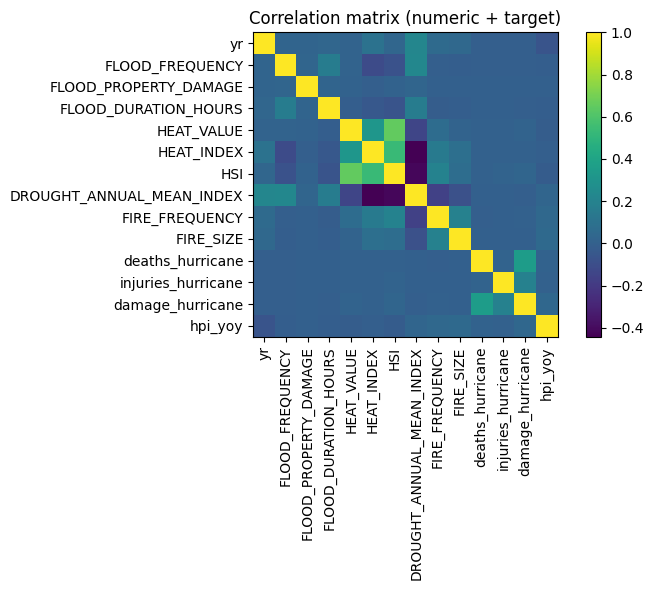

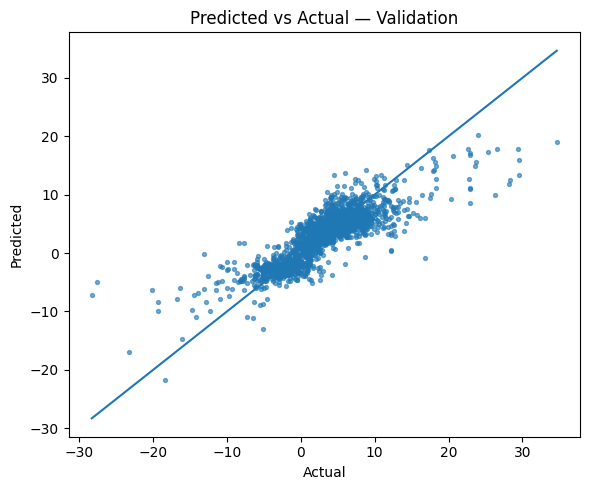

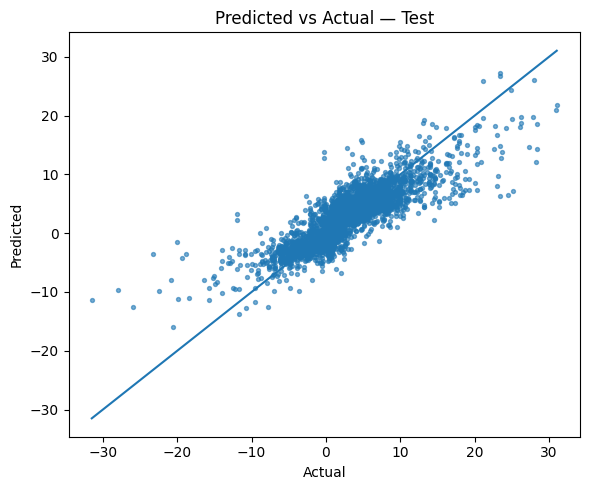

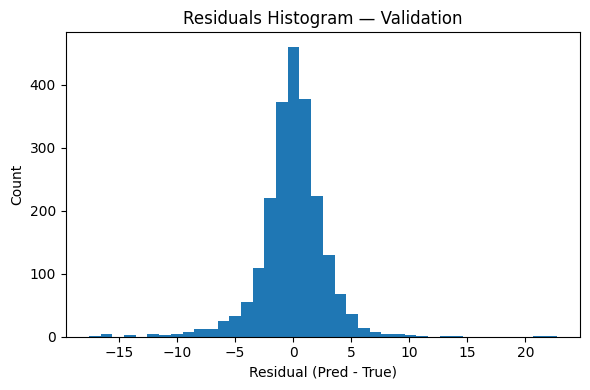

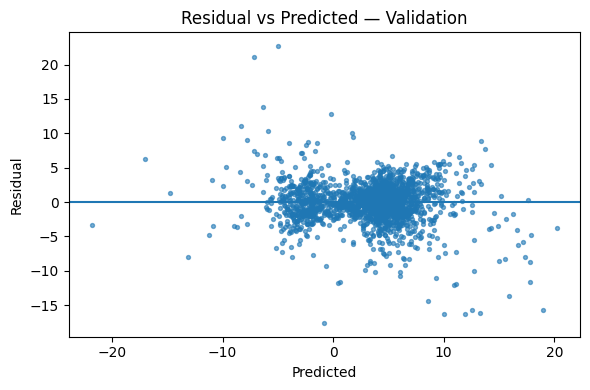

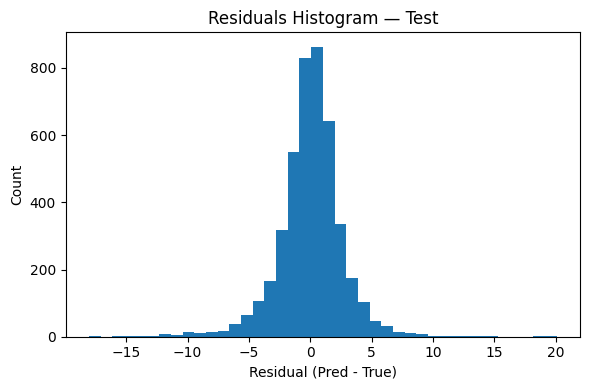

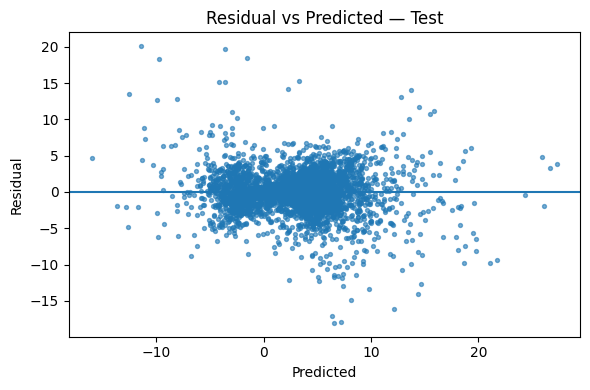


=== Validation Directional (up vs not-up) ===
Accuracy : 0.9413
Precision: 0.9684
Recall   : 0.9580
F1       : 0.9632


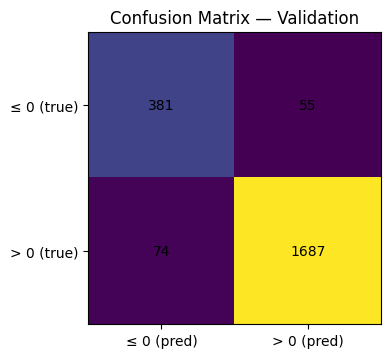


=== Test Directional (up vs not-up) ===
Accuracy : 0.9256
Precision: 0.9571
Recall   : 0.9498
F1       : 0.9534


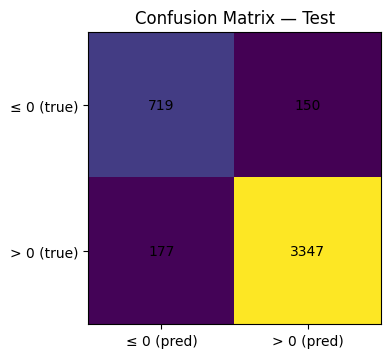

In [ ]:
# -------------------------------
# 7) Evaluate (Validation + Test) — version-safe + extras
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
from inspect import signature
from sklearn.metrics import mean_squared_error as _mse, mean_absolute_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


def _rmse(y_true, y_pred):
    try:
        if "squared" in signature(_mse).parameters:
            return _mse(y_true, y_pred, squared=False)
    except Exception:
        pass
    return np.sqrt(_mse(y_true, y_pred))


def _mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0


def report_metrics(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    rmse = _rmse(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = _mape(y_true, y_pred)
    print(f"\n=== {name} Performance ===")
    print(f"RMSE : {rmse:,.4f}")
    print(f"MAE  : {mae:,.4f}")
    print(f"R^2  : {r2:,.4f}")
    print(f"MAPE : {mape:,.2f}%")


# Predictions from the trained (early-stopped) model
y_val_pred = xgb.predict(Xva)
y_test_pred = xgb.predict(Xte)

report_metrics("Validation", y_val, y_val_pred)
report_metrics("Test", y_test, y_test_pred)

# ---- Correlation matrix (numeric + target) ----
num_for_corr = [c for c in numeric_cols if c in df.columns]
if target_col not in num_for_corr:
    num_for_corr.append(target_col)
corr_df = df[num_for_corr].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_df, interpolation="nearest")
plt.xticks(np.arange(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(np.arange(len(corr_df.index)), corr_df.index)
plt.title("Correlation matrix (numeric + target)")
plt.colorbar()
plt.tight_layout()
plt.show()


# ---- Charts: Predicted vs Actual, Residuals ----
def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, s=8, alpha=0.6)
    lo = float(min(np.min(y_true), np.min(y_pred)))
    hi = float(max(np.max(y_true), np.max(y_pred)))
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title_hist, title_scatter):
    resid = y_pred - y_true
    plt.figure(figsize=(6, 4))
    plt.hist(resid, bins=40)
    plt.xlabel("Residual (Pred - True)")
    plt.ylabel("Count")
    plt.title(title_hist)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, resid, s=8, alpha=0.6)
    plt.axhline(0)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(title_scatter)
    plt.tight_layout()
    plt.show()


plot_pred_vs_actual(y_val, y_val_pred, "Predicted vs Actual — Validation")
plot_pred_vs_actual(y_test, y_test_pred, "Predicted vs Actual — Test")
plot_residuals(
    y_val,
    y_val_pred,
    "Residuals Histogram — Validation",
    "Residual vs Predicted — Validation",
)
plot_residuals(
    y_test, y_test_pred, "Residuals Histogram — Test", "Residual vs Predicted — Test"
)


# ---- Directional (classification-style) metrics: did HPI go up (>0)? ----
def directional_report(name, y_true, y_pred):
    y_true_bin = (np.asarray(y_true) > 0).astype(int)
    y_pred_bin = (np.asarray(y_pred) > 0).astype(int)
    acc = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    print(f"\n=== {name} Directional (up vs not-up) ===")
    print(f"Accuracy : {acc:,.4f}")
    print(f"Precision: {prec:,.4f}")
    print(f"Recall   : {rec:,.4f}")
    print(f"F1       : {f1:,.4f}")
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix — {name}")
    plt.xticks([0, 1], ["≤ 0 (pred)", "> 0 (pred)"])
    plt.yticks([0, 1], ["≤ 0 (true)", "> 0 (true)"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.show()


directional_report("Validation", y_val, y_val_pred)
directional_report("Test", y_test, y_test_pred)


# # -------------------------------
# # 7) Evaluate (Validation + Test) — version-safe + extras
# # -------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from inspect import signature
# from sklearn.metrics import mean_squared_error as _mse, mean_absolute_error, r2_score
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# def _rmse(y_true, y_pred):
#     try:
#         if 'squared' in signature(_mse).parameters:
#             return _mse(y_true, y_pred, squared=False)
#     except Exception:
#         pass
#     return np.sqrt(_mse(y_true, y_pred))

# def _mape(y_true, y_pred, eps=1e-8):
#     y_true = np.asarray(y_true, dtype=float).ravel()
#     y_pred = np.asarray(y_pred, dtype=float).ravel()
#     denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
#     return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

# def report_metrics(name, y_true, y_pred):
#     y_true = np.asarray(y_true, dtype=float).ravel()
#     y_pred = np.asarray(y_pred, dtype=float).ravel()
#     rmse = _rmse(y_true, y_pred)
#     mae  = mean_absolute_error(y_true, y_pred)
#     r2   = r2_score(y_true, y_pred)
#     mape = _mape(y_true, y_pred)
#     print(f"\n=== {name} Performance ===")
#     print(f"RMSE : {rmse:,.4f}")
#     print(f"MAE  : {mae:,.4f}")
#     print(f"R^2  : {r2:,.4f}")
#     print(f"MAPE : {mape:,.2f}%")

# # Predictions from the trained (early-stopped) model
# y_val_pred  = xgb.predict(Xva)
# y_test_pred = xgb.predict(Xte)

# report_metrics("Validation", y_val, y_val_pred)
# report_metrics("Test",       y_test, y_test_pred)

# # ---- Correlation matrix (numeric + target) restricted to valid years used in the split ----
# # This matches the "valid_mask" logic from Section 4 (rows with a numeric year).
# year_col = "yr"  # same as in Section 4
# years_numeric = pd.to_numeric(df[year_col], errors="coerce")
# df_valid_year = df.loc[years_numeric.notna()].copy()

# num_for_corr = [c for c in numeric_cols if c in df_valid_year.columns]
# if target_col not in num_for_corr:
#     num_for_corr.append(target_col)
# corr_df = df_valid_year[num_for_corr].corr()

# plt.figure(figsize=(8, 6))
# plt.imshow(corr_df, interpolation='nearest')
# plt.xticks(np.arange(len(corr_df.columns)), corr_df.columns, rotation=90)
# plt.yticks(np.arange(len(corr_df.index)),   corr_df.index)
# plt.title("Correlation matrix (numeric + target, valid years only)")
# plt.colorbar()
# plt.tight_layout()
# plt.show()

# # ---- Charts: Predicted vs Actual, Residuals ----
# def plot_pred_vs_actual(y_true, y_pred, title):
#     plt.figure(figsize=(6,5))
#     plt.scatter(y_true, y_pred, s=8, alpha=0.6)
#     lo = float(min(np.min(y_true), np.min(y_pred)))
#     hi = float(max(np.max(y_true), np.max(y_pred)))
#     plt.plot([lo, hi], [lo, hi])
#     plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title(title)
#     plt.tight_layout(); plt.show()

# def plot_residuals(y_true, y_pred, title_hist, title_scatter):
#     resid = y_pred - y_true
#     plt.figure(figsize=(6,4))
#     plt.hist(resid, bins=40)
#     plt.xlabel("Residual (Pred - True)"); plt.ylabel("Count"); plt.title(title_hist)
#     plt.tight_layout(); plt.show()

#     plt.figure(figsize=(6,4))
#     plt.scatter(y_pred, resid, s=8, alpha=0.6); plt.axhline(0)
#     plt.xlabel("Predicted"); plt.ylabel("Residual"); plt.title(title_scatter)
#     plt.tight_layout(); plt.show()

# plot_pred_vs_actual(y_val,  y_val_pred,  "Predicted vs Actual — Validation")
# plot_pred_vs_actual(y_test, y_test_pred, "Predicted vs Actual — Test")
# plot_residuals(y_val,  y_val_pred,  "Residuals Histogram — Validation", "Residual vs Predicted — Validation")
# plot_residuals(y_test, y_test_pred, "Residuals Histogram — Test",       "Residual vs Predicted — Test")

# # ---- Directional (classification-style) metrics: did HPI go up (>0)? ----
# def directional_report(name, y_true, y_pred):
#     y_true_bin = (np.asarray(y_true) > 0).astype(int)
#     y_pred_bin = (np.asarray(y_pred) > 0).astype(int)
#     acc  = accuracy_score(y_true_bin, y_pred_bin)
#     prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
#     rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
#     f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
#     cm   = confusion_matrix(y_true_bin, y_pred_bin, labels=[0,1])
#     print(f"\n=== {name} Directional (up vs not-up) ===")
#     print(f"Accuracy : {acc:,.4f}")
#     print(f"Precision: {prec:,.4f}")
#     print(f"Recall   : {rec:,.4f}")
#     print(f"F1       : {f1:,.4f}")
#     plt.figure(figsize=(4,4))
#     plt.imshow(cm, interpolation='nearest')
#     plt.title(f"Confusion Matrix — {name}")
#     plt.xticks([0,1], ["≤ 0 (pred)", "> 0 (pred)"])
#     plt.yticks([0,1], ["≤ 0 (true)", "> 0 (true)"])
#     for (i,j), v in np.ndenumerate(cm):
#         plt.text(j, i, str(v), ha='center', va='center')
#     plt.tight_layout(); plt.show()

# directional_report("Validation", y_val,  y_val_pred)
# directional_report("Test",       y_test, y_test_pred)


Top 30 features by importance:
                                feature  importance
                                num__yr    0.029592
                     cat__STATE_FLORIDA    0.029273
                  cat__STATE_CALIFORNIA    0.023469
                    cat__STATE_MARYLAND    0.019895
                    cat__STATE_VIRGINIA    0.019668
                      cat__STATE_NEVADA    0.018601
                       cat__STATE_TEXAS    0.017832
                     cat__STATE_ARIZONA    0.015820
                cat__STATE_NORTH DAKOTA    0.011245
                    num__FIRE_FREQUENCY    0.009303
                    cat__STATE_COLORADO    0.008762
                         cat__CZ_NAME_0    0.007906
                      cat__STATE_OREGON    0.007628
                   cat__STATE_MINNESOTA    0.007546
                    cat__STATE_ILLINOIS    0.007128
                       cat__STATE_IDAHO    0.007030
                   cat__STATE_LOUISIANA    0.006916
                   cat__STATE_TE

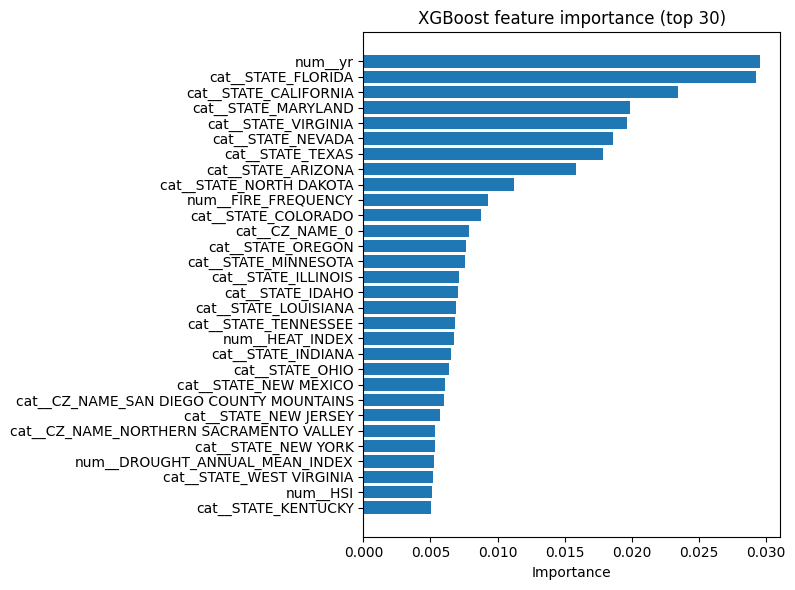

In [ ]:
# -------------------------------
# 8) Feature importances
# -------------------------------
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": xgb.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 30 features by importance:")
print(imp_df.head(30).to_string(index=False))

# Optional: bar chart (top 20)
topk = min(30, len(imp_df))
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"].head(topk)[::-1], imp_df["importance"].head(topk)[::-1])
plt.xlabel("Importance")
plt.title("XGBoost feature importance (top 30)")
plt.tight_layout()
plt.show()


# # -------------------------------
# # 8) Feature importances
# # -------------------------------
# imp_df = (
#     pd.DataFrame({"feature": feature_names, "importance": xgb.feature_importances_})
#     .sort_values("importance", ascending=False)
#     .reset_index(drop=True)
# )

# print("\nTop 30 features by importance:")
# print(imp_df.head(30).to_string(index=False))

# # Optional: bar chart (top 30)
# topk = min(30, len(imp_df))
# plt.figure(figsize=(8, 6))
# plt.barh(imp_df["feature"].head(topk)[::-1], imp_df["importance"].head(topk)[::-1])
# plt.xlabel("Importance"); plt.title("XGBoost feature importance (top 30)")
# plt.tight_layout(); plt.show()